# Penghitungan Inter-Annotator Agreement (Krippendorff’s Alpha)

1. Load data dari 3 file spreadsheet anotator (Google Drive)
2. Cek kelengkapan label per anotator
3. Hitung Krippendorff's Alpha per aspek dan keseluruhan
4. Majority Voting untuk menghasilkan label final
5. Export hasil ke file Excel
6. Eksplorasi dan visualisasi distribusi label final

---
**Aspek:** `Room`, `Hotel`, `Location`, `Service` | **Label:** `None`, `Positive`, `Negative` | **Anotator:** A1, A2, A3



## 1. Instalasi & Import Library


In [1]:
# Install library
!pip install krippendorff openpyxl xlsxwriter wordcloud --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 656.1 kB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import krippendorff
import warnings
import os
from collections import Counter
from google.colab import drive
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

print("Library berhasil diimport.")

Library berhasil diimport.


## 2. Mount Google Drive & Konfigurasi Path File Pelabelan

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
FILE_A1 = "/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Pelabelan_Annotator_1.xlsx"
FILE_A2 = "/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Pelabelan_Annotator_2.xlsx"
FILE_A3 = "/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Pelabelan_Annotator_3.xlsx"

# Nama sheet pelabelan di masing-masing file
SHEET_A1 = 'Pelabelan A1'
SHEET_A2 = 'Pelabelan A2'
SHEET_A3 = 'Pelabelan A3'

# Kolom identitas
ASPEK_COLS  = ['Room', 'Hotel', 'Location', 'Service']
ID_COL      = 'id'
TEXT_COL    = 'review_text'
TRANS_COL   = 'review_text_translated'
VALID_LABELS = ['None', 'Positive', 'Negative']

# Folder output hasil
OUTPUT_DIR  = '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Finalisasi_Label/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Konfigurasi selesai. Output: {OUTPUT_DIR}")

Konfigurasi selesai. Output: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Finalisasi_Label/


## Load Data Anotator

In [5]:
def load_annotator_file(filepath, sheet_name, annotator_name):
    """Load file Excel anotator, lakukan standarisasi nama kolom dan nilai label."""
    try:
        df = pd.read_excel(filepath, sheet_name=sheet_name)
        df.columns = df.columns.str.strip()
        for col in ASPEK_COLS:
            if col in df.columns:
                df[col] = df[col].astype(str).str.strip().str.capitalize()
                df[col] = df[col].replace({
                    'Nan': 'None', 'nan': 'None', '': 'None',
                    'positive': 'Positive', 'POSITIVE': 'Positive',
                    'negative': 'Negative', 'NEGATIVE': 'Negative'
                })
            else:
                print(f"  [!] Kolom '{col}' tidak ditemukan di {annotator_name}")
        print(f"[OK] {annotator_name}: {len(df)} baris dari sheet '{sheet_name}'")
        return df
    except Exception as e:
        print(f"[ERROR] {annotator_name}: {e}")
        return None

df_a1 = load_annotator_file(FILE_A1, SHEET_A1, 'Anotator A1')
df_a2 = load_annotator_file(FILE_A2, SHEET_A2, 'Anotator A2')
df_a3 = load_annotator_file(FILE_A3, SHEET_A3, 'Anotator A3')

[OK] Anotator A1: 7821 baris dari sheet 'Pelabelan A1'
[OK] Anotator A2: 7821 baris dari sheet 'Pelabelan A2'
[OK] Anotator A3: 7821 baris dari sheet 'Pelabelan A3'


In [ ]:
# Preview data A1
print("=== Preview Data Anotator A1 ===")
print(f"Shape: {df_a1.shape}")
df_a1.head()

=== Preview Data Anotator A1 ===
Shape: (7821, 7)


,id,review_text,review_text_translated,Room,Hotel,Location,Service
0,1,Pertama kali disini super kagum sama interior hotel <3\nauthentic banget kam...,Pertama kali disini super kagum sama interior hotel <3\nauthentic banget kam...,Positive,Positive,None,None
1,2,"Pelayanan oke banget dibantu dengan resepsionis yang sangat ramah sekali, pe...","Pelayanan oke banget dibantu dengan resepsionis yang sangat ramah sekali, pe...",None,None,None,Positive
2,3,Kolam renang dan gym nya sangat bagus dan yang terbaik dari hotel lain.,Kolam renang dan gym nya sangat bagus dan yang terbaik dari hotel lain.,None,Positive,None,None
3,4,Kami Sekeluarga senang. Kamarnya bersih dan nyaman. Area taman nya sangat ra...,Kami Sekeluarga senang. Kamarnya bersih dan nyaman. Area taman nya sangat ra...,Positive,Positive,None,None
4,5,Perbotan kamar seperti AC dan dispenser air minum sering kali tidak berfungs...,Perbotan kamar seperti AC dan dispenser air minum sering kali tidak berfungs...,Negative,None,None,None


## Cek Kelengkapan Label

Baris dianggap belum dilabeli jika **semua aspek bernilai 'None'** (anotator belum mengisi sama sekali).

In [6]:
def cek_kelengkapan(df, annotator_name):
    """Cek baris yang belum dilabeli dan nilai tidak valid."""
    print(f"\n{'='*50}")
    print(f"  Cek Kelengkapan: {annotator_name}")
    print(f"{'='*50}")

    # 1. Cek nilai tidak valid
    print("\nDistribusi nilai per aspek:")
    for col in ASPEK_COLS:
        dist = df[col].value_counts().to_dict()
        invalid = {k: v for k, v in dist.items() if k not in VALID_LABELS}
        print(f"  {col:12s}: {dist}")
        if invalid:
            print(f"  [!] Nilai tidak valid di '{col}': {invalid}")

    # 2. Baris dengan SEMUA aspek = None (kemungkinan belum dilabeli)
    all_none = (df[ASPEK_COLS] == 'None').all(axis=1)
    df_belum = df[all_none]
    print(f"\nTotal baris          : {len(df)}")
    print(f"Belum dilabeli (all None): {len(df_belum)}")
    if len(df_belum) > 0:
        print(f"ID belum dilabeli: {df_belum[ID_COL].tolist()}")
    else:
        print("✅ Semua baris sudah dilabeli.")
    return df_belum

belum_a1 = cek_kelengkapan(df_a1, 'Anotator A1')
belum_a2 = cek_kelengkapan(df_a2, 'Anotator A2')
belum_a3 = cek_kelengkapan(df_a3, 'Anotator A3')


  Cek Kelengkapan: Anotator A1

Distribusi nilai per aspek:
  Room        : {'None': 4414, 'Negative': 1811, 'Positive': 1596}
  Hotel       : {'None': 4542, 'Positive': 1999, 'Negative': 1280}
  Location    : {'None': 5180, 'Positive': 2036, 'Negative': 605}
  Service     : {'None': 5036, 'Positive': 1790, 'Negative': 995}

Total baris          : 7821
Belum dilabeli (all None): 0
✅ Semua baris sudah dilabeli.

  Cek Kelengkapan: Anotator A2

Distribusi nilai per aspek:
  Room        : {'None': 4315, 'Negative': 1823, 'Positive': 1683}
  Hotel       : {'None': 4348, 'Positive': 2077, 'Negative': 1396}
  Location    : {'None': 5168, 'Positive': 2021, 'Negative': 632}
  Service     : {'None': 4997, 'Positive': 1798, 'Negative': 1026}

Total baris          : 7821
Belum dilabeli (all None): 0
✅ Semua baris sudah dilabeli.

  Cek Kelengkapan: Anotator A3

Distribusi nilai per aspek:
  Room        : {'None': 4416, 'Negative': 1803, 'Positive': 1602}
  Hotel       : {'None': 4480, 'Positive'

## Merge Data Ketiga Anotator
Menggabungkan label ketiga anotator berdasarkan kolom `id`. Kolom label setiap anotator diberi suffix `_A1`, `_A2`, `_A3`.

In [7]:
def prepare_merge(df, suffix):
    """Pilih kolom id + aspek, rename kolom aspek dengan suffix anotator."""
    cols = [ID_COL] + ASPEK_COLS
    df_sel = df[cols].copy()
    rename_map = {col: f"{col}_{suffix}" for col in ASPEK_COLS}
    df_sel = df_sel.rename(columns=rename_map)
    return df_sel


df_m1 = prepare_merge(df_a1, 'A1')
df_m2 = prepare_merge(df_a2, 'A2')
df_m3 = prepare_merge(df_a3, 'A3')

# Merge berdasarkan id
df_merged = df_m1.merge(df_m2, on=ID_COL, how='inner') \
                  .merge(df_m3, on=ID_COL, how='inner')

# Tambahkan kolom teks dari A1 sebagai referensi
text_cols = [ID_COL, TEXT_COL, TRANS_COL] if TRANS_COL in df_a1.columns else [ID_COL, TEXT_COL]
df_texts = df_a1[[c for c in text_cols if c in df_a1.columns]].copy()
df_merged = df_texts.merge(df_merged, on=ID_COL, how='inner')

print(f"✅ Data berhasil digabung!")
print(f"   Total baris yang cocok (inner join): {len(df_merged)}")
print(f"   Total kolom: {len(df_merged.columns)}")
df_merged.head(3)

✅ Data berhasil digabung!
   Total baris yang cocok (inner join): 7821
   Total kolom: 15


,id,review_text,review_text_translated,Room_A1,Hotel_A1,Location_A1,Service_A1,Room_A2,Hotel_A2,Location_A2,Service_A2,Room_A3,Hotel_A3,Location_A3,Service_A3
0,1,Pertama kali disini super kagum sama interior hotel <3\nauthentic banget kam...,Pertama kali disini super kagum sama interior hotel <3\nauthentic banget kam...,Positive,Positive,None,None,Positive,Positive,None,None,Positive,Positive,None,None
1,2,"Pelayanan oke banget dibantu dengan resepsionis yang sangat ramah sekali, pe...","Pelayanan oke banget dibantu dengan resepsionis yang sangat ramah sekali, pe...",None,None,None,Positive,None,None,None,Positive,None,None,None,Positive
2,3,Kolam renang dan gym nya sangat bagus dan yang terbaik dari hotel lain.,Kolam renang dan gym nya sangat bagus dan yang terbaik dari hotel lain.,None,Positive,None,None,None,Positive,None,None,None,Positive,None,None


## 6. Ekspor Data Gabungan Anotator (Sebelum Majority Voting)

File ini berisi review text, lalu untuk setiap aspek ditampilkan label dari A1, A2, A3 secara berdampingan. Untuk dokumentasi dan verifikasi manual.

In [ ]:
# Kolom: id, teks, lalu per aspek: [Aspek_A1, Aspek_A2, Aspek_A3]
gabungan_cols = [ID_COL]
if TEXT_COL in df_merged.columns:
    gabungan_cols.append(TEXT_COL)
if TRANS_COL in df_merged.columns:
    gabungan_cols.append(TRANS_COL)
for aspek in ASPEK_COLS:
    gabungan_cols += [f"{aspek}_A1", f"{aspek}_A2", f"{aspek}_A3"]

df_gabungan = df_merged[[c for c in gabungan_cols if c in df_merged.columns]].copy()

# Simpan ke Excel
path_gabungan = OUTPUT_DIR + 'Data_Gabungan_Anotator.xlsx'
df_gabungan.to_excel(path_gabungan, index=False)

print(f"✅ File gabungan disimpan: {path_gabungan}")
print(f"   Shape: {df_gabungan.shape}")
df_gabungan.head(3)

✅ File gabungan disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Finalisasi_Label/Data_Gabungan_Anotator.xlsx
   Shape: (7821, 15)


,id,review_text,review_text_translated,Room_A1,Room_A2,Room_A3,Hotel_A1,Hotel_A2,Hotel_A3,Location_A1,Location_A2,Location_A3,Service_A1,Service_A2,Service_A3
0,1,Pertama kali disini super kagum sama interior hotel <3\nauthentic banget kam...,Pertama kali disini super kagum sama interior hotel <3\nauthentic banget kam...,Positive,Positive,Positive,Positive,Positive,Positive,None,None,None,None,None,None
1,2,"Pelayanan oke banget dibantu dengan resepsionis yang sangat ramah sekali, pe...","Pelayanan oke banget dibantu dengan resepsionis yang sangat ramah sekali, pe...",None,None,None,None,None,None,None,None,None,Positive,Positive,Positive
2,3,Kolam renang dan gym nya sangat bagus dan yang terbaik dari hotel lain.,Kolam renang dan gym nya sangat bagus dan yang terbaik dari hotel lain.,None,None,None,Positive,Positive,Positive,None,None,None,None,None,None


## Hitung Krippendorff's Alpha per Aspek

Krippendorff's Alpha mengukur tingkat kesepakatan antar anotator dengan memperhitungkan kemungkinan kesepakatan secara kebetulan. Karena label bersifat **nominal** (None/Positive/Negative), digunakan `level_of_measurement='nominal'`.

Penghitungan dilakukan **per aspek** dan **secara keseluruhan** (seluruh label digabung).

### 7a. Tabel Panduan Interpretasi

Terdapat dua skema interpretasi yang umum digunakan. Keduanya ditampilkan di bawah ini; pilih salah satu sesuai arahan dosen pembimbing.

**Skema A — Krippendorff (2019)** *(direkomendasikan untuk studi anotasi teks/NLP)*

| Nilai Alpha | Interpretasi |
|:-----------:|:-------------|
| α = 1 | Kesepakatan sempurna |
| α ≥ 0.80 | Reliabel — dapat digunakan untuk penarikan kesimpulan |
| 0.67 ≤ α < 0.80 | Kesimpulan tentatif — perlu dikaji lebih lanjut |
| α < 0.67 | Tidak reliabel — data tidak layak digunakan |
| α = 0 | Kesepakatan setara dengan peluang (acak) |
| α < 0 | Ketidaksepakatan sistematis |

**Skema B — Landis & Koch (1977)**

| Nilai Alpha | Interpretasi |
|:-----------:|:-------------|
| α ≤ 0.20 | Slight Agreement |
| 0.20 < α ≤ 0.40 | Fair Agreement |
| 0.40 < α ≤ 0.60 | Moderate Agreement |
| 0.60 < α ≤ 0.80 | Substantial Agreement |
| α > 0.80 | Near-Perfect Agreement |

In [8]:
LABEL_MAP = {'None': 0, 'Positive': 1, 'Negative': 2}

def hitung_alpha(labels_a1, labels_a2, labels_a3):
    """Hitung Krippendorff's Alpha dari tiga seri label nominal."""
    to_num = lambda s: s.map(LABEL_MAP).values.astype(float)
    matrix = np.array([to_num(labels_a1), to_num(labels_a2), to_num(labels_a3)])
    return round(krippendorff.alpha(reliability_data=matrix, level_of_measurement='nominal'), 4)

def interpretasi_krippendorff(alpha_val, skema='A'):
    """Interpretasi nilai alpha. skema='A' = Krippendorff; skema='B' = Landis & Koch."""
    if skema == 'A':
        if alpha_val >= 0.80:
            return "Reliabel"
        elif alpha_val >= 0.67:
            return "Kesimpulan Tentatif"
        elif alpha_val > 0:
            return "Tidak Reliabel"
        elif alpha_val == 0:
            return "Acak"
        else:
            return "Ketidaksepakatan Sistematis"
    else:  # Skema B
        if alpha_val <= 0.20:
            return "Slight Agreement"
        elif alpha_val <= 0.40:
            return "Fair Agreement"
        elif alpha_val <= 0.60:
            return "Moderate Agreement"
        elif alpha_val <= 0.80:
            return "Substantial Agreement"
        else:
            return "Near-Perfect Agreement"

### 7b. Hasil Krippendorff's Alpha — Skema A (Krippendorff, 2019)

In [9]:
hasil_alpha = []

# Per aspek
for aspek in ASPEK_COLS:
    a = hitung_alpha(
        df_merged[f"{aspek}_A1"],
        df_merged[f"{aspek}_A2"],
        df_merged[f"{aspek}_A3"]
    )
    hasil_alpha.append({
        'Aspek': aspek,
        "Krippendorff's Alpha": a,
        'Interpretasi (Skema A)': interpretasi_krippendorff(a, 'A'),
        'Interpretasi (Skema B)': interpretasi_krippendorff(a, 'B')
    })

# Keseluruhan (semua aspek digabung)
all_a1 = pd.concat([df_merged[f"{a}_A1"] for a in ASPEK_COLS], ignore_index=True)
all_a2 = pd.concat([df_merged[f"{a}_A2"] for a in ASPEK_COLS], ignore_index=True)
all_a3 = pd.concat([df_merged[f"{a}_A3"] for a in ASPEK_COLS], ignore_index=True)
a_all  = hitung_alpha(all_a1, all_a2, all_a3)
hasil_alpha.append({
    'Aspek': 'KESELURUHAN',
    "Krippendorff's Alpha": a_all,
    'Interpretasi (Skema A)': interpretasi_krippendorff(a_all, 'A'),
    'Interpretasi (Skema B)': interpretasi_krippendorff(a_all, 'B')
})

df_alpha = pd.DataFrame(hasil_alpha)
print(df_alpha.to_string(index=False))

      Aspek  Krippendorff's Alpha Interpretasi (Skema A) Interpretasi (Skema B)
       Room                0.9585               Reliabel Near-Perfect Agreement
      Hotel                0.9386               Reliabel Near-Perfect Agreement
   Location                0.9639               Reliabel Near-Perfect Agreement
    Service                0.9636               Reliabel Near-Perfect Agreement
KESELURUHAN                0.9561               Reliabel Near-Perfect Agreement


In [ ]:
import krippendorff

LABEL_MAP = {'None': 0, 'Positive': 1, 'Negative': 2}

# Fungsi interpretasi
def interpretasi_alpha(alpha):
  if alpha_val >= 0.80: return "Reliabel"
  elif alpha_val >= 0.67: return "Kesimpulan Tentatif"
  elif alpha_val > 0: return "Tidak Reliabel"
  elif alpha_val == 0: return "Acak"
  else: return "Ketidaksepakatan Sistematis"

# Fungsi hitung Krippendorff’s Alpha
def hitung_alpha(a1, a2, a3):
    data = np.array([
        a1.map(LABEL_MAP), a2.map(LABEL_MAP), a3.map(LABEL_MAP)
    ])
    return round(krippendorff.alpha(reliability_data=data, level_of_measurement='nominal'), 4)

ASPEK_COLS = ['Room', 'Hotel', 'Location', 'Service']
hasil = []

for aspek in ASPEK_COLS:
    alpha = hitung_alpha(
        df_merged[f"{aspek}_A1"], df_merged[f"{aspek}_A2"], df_merged[f"{aspek}_A3"]
    )
    hasil.append({
        'Aspek': aspek, "Krippendorff's Alpha": alpha, 'Interpretasi': interpretasi_alpha(alpha)
    })


# Keseluruhan (gabungan semua aspek)
all_a1 = pd.concat([df_merged[f"{a}_A1"] for a in ASPEK_COLS], ignore_index=True)
all_a2 = pd.concat([df_merged[f"{a}_A2"] for a in ASPEK_COLS], ignore_index=True)
all_a3 = pd.concat([df_merged[f"{a}_A3"] for a in ASPEK_COLS], ignore_index=True)

alpha_all = hitung_alpha(all_a1, all_a2, all_a3)

hasil.append({
    'Aspek': 'KESELURUHAN',
    "Krippendorff's Alpha": alpha_all,
    'Interpretasi': interpretasi_alpha(alpha_all)
})

# Tampilkan hasil
df_alpha = pd.DataFrame(hasil)
print(df_alpha)

### 7c. Visualisasi Krippendorff's Alpha

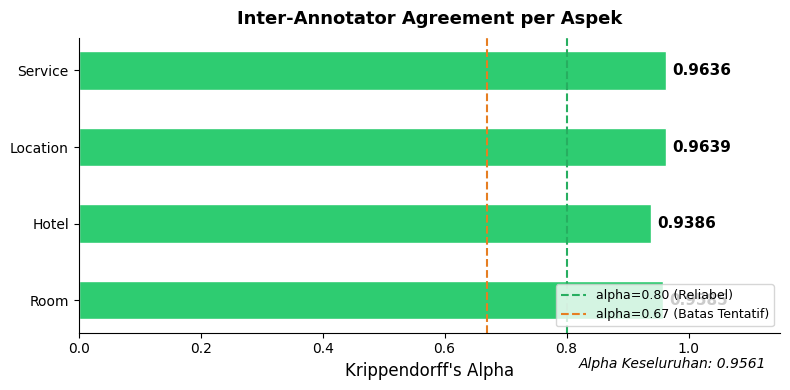

Grafik disimpan.


In [ ]:
df_plot = df_alpha[df_alpha['Aspek'] != 'KESELURUHAN'].copy()
alphas  = df_alpha[df_alpha['Aspek'] == 'KESELURUHAN']["Krippendorff's Alpha"].values[0]

colors = []
for v in df_plot["Krippendorff's Alpha"]:
    if v >= 0.80:   colors.append('#2ecc71')
    elif v >= 0.67: colors.append('#f39c12')
    else:           colors.append('#e74c3c')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(df_plot['Aspek'], df_plot["Krippendorff's Alpha"],
               color=colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, df_plot["Krippendorff's Alpha"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

ax.axvline(x=0.80, color='#27ae60', linestyle='--', linewidth=1.5, label='alpha=0.80 (Reliabel)')
ax.axvline(x=0.67, color='#e67e22', linestyle='--', linewidth=1.5, label='alpha=0.67 (Batas Tentatif)')
ax.set_xlim(0, 1.15)
ax.set_xlabel("Krippendorff's Alpha", fontsize=12)
ax.set_title("Inter-Annotator Agreement per Aspek", fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=9, loc='lower right')
ax.spines[['top','right']].set_visible(False)

# Anotasi alpha keseluruhan
ax.text(0.98, -0.12, f"Alpha Keseluruhan: {alphas:.4f}",
        transform=ax.transAxes, ha='right', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'krippendorff_alpha.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan.")

## Majority Voting

**Majority Voting** menentukan label final berdasarkan suara terbanyak dari 3 anotator.
- Jika **2 atau 3 anotator sepakat** → label tersebut menjadi label final
- Jika **ketiganya berbeda** (tidak ada mayoritas) → dicatat sebagai `'Conflict'` untuk ditinjau manual

In [8]:
def majority_vote(row, aspek):
    votes = [row[f"{aspek}_A1"], row[f"{aspek}_A2"], row[f"{aspek}_A3"]]
    most_common = Counter(votes).most_common()
    return most_common[0][0] if most_common[0][1] >= 2 else 'Conflict'

for aspek in ASPEK_COLS:
    df_merged[f"{aspek}_Final"] = df_merged.apply(lambda r: majority_vote(r, aspek), axis=1)

print("Hasil Majority Voting per Aspek:")
print("-" * 55)
for aspek in ASPEK_COLS:
    dist = df_merged[f"{aspek}_Final"].value_counts()
    n_conflict = (df_merged[f"{aspek}_Final"] == 'Conflict').sum()
    print(f"\nAspek: {aspek}")
    for label, count in dist.items():
        print(f"  {label:12s}: {count:5d} ({count/len(df_merged)*100:.1f}%)")
    if n_conflict > 0:
        print(f"  [!] Conflict: {n_conflict} baris — perlu review manual")

Hasil Majority Voting per Aspek:
-------------------------------------------------------

Aspek: Room
  None        :  4414 (56.4%)
  Negative    :  1812 (23.2%)
  Positive    :  1595 (20.4%)

Aspek: Hotel
  None        :  4540 (58.0%)
  Positive    :  2001 (25.6%)
  Negative    :  1280 (16.4%)

Aspek: Location
  None        :  5179 (66.2%)
  Positive    :  2039 (26.1%)
  Negative    :   603 (7.7%)

Aspek: Service
  None        :  5042 (64.5%)
  Positive    :  1784 (22.8%)
  Negative    :   995 (12.7%)


In [9]:
# Tampilkan baris conflict (jika ada)
conflict_mask = (df_merged[[f"{a}_Final" for a in ASPEK_COLS]] == 'Conflict').any(axis=1)
df_conflict   = df_merged[conflict_mask].copy()

print(f"⚠️  Total baris dengan Conflict: {len(df_conflict)}")
if len(df_conflict) > 0:
    df_conflict.head(10)

⚠️  Total baris dengan Conflict: 0


## 8. Export Hasil ke Excel

Menyimpan seluruh hasil ke file Excel dengan beberapa sheet:
- **Label_Final** → hasil majority voting siap digunakan
- **Semua_Label** → perbandingan label ketiga anotator + label final
- **Krippendorff_Alpha** → tabel nilai alpha per aspek + interpretasi (kedua skema)
- **Conflict** → baris yang perlu ditinjau manual (jika ada)

In [ ]:
OUTPUT_FILE = OUTPUT_DIR + 'Hasil_Pelabelan_Final.xlsx'

# DataFrame Label Final
final_cols = [c for c in [ID_COL, TEXT_COL, TRANS_COL] if c in df_merged.columns]
final_cols += [f"{a}_Final" for a in ASPEK_COLS]
df_final = df_merged[final_cols].copy().rename(columns={f"{a}_Final": a for a in ASPEK_COLS})

# DataFrame Semua Label (A1/A2/A3 + Final, per aspek berdampingan) ---
# Kolom: id, review_text, review_text_translated,
#         Room_A1, Room_A2, Room_A3, Room_Final,
#         Hotel_A1, Hotel_A2, Hotel_A3, Hotel_Final, dst.
semua_cols = [c for c in [ID_COL, TEXT_COL, TRANS_COL] if c in df_merged.columns]
for a in ASPEK_COLS:
    semua_cols += [f"{a}_A1", f"{a}_A2", f"{a}_A3", f"{a}_Final"]
df_semua = df_merged[[c for c in semua_cols if c in df_merged.columns]].copy()

# Simpan
with pd.ExcelWriter(OUTPUT_FILE, engine='xlsxwriter') as writer:
    df_final.to_excel(writer, sheet_name='Label_Final', index=False)
    df_semua.to_excel(writer, sheet_name='Semua_Label', index=False)
    df_alpha.to_excel(writer, sheet_name='Krippendorff_Alpha', index=False)
    if len(df_conflict) > 0:
        df_conflict.to_excel(writer, sheet_name='Conflict', index=False)

    for sn in writer.sheets:
        writer.sheets[sn].set_column(0, 30, 18)

print(f"File disimpan: {OUTPUT_FILE}")
print(f"Sheet: Label_Final | Semua_Label | Krippendorff_Alpha" +
      (" | Conflict" if len(df_conflict) > 0 else ""))

File disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Finalisasi_Label/Hasil_Pelabelan_Final.xlsx
Sheet: Label_Final | Semua_Label | Krippendorff_Alpha


## 10. Eksplorasi & Visualisasi Label Final

Untuk memvisualisasikan distribusi label final (Positive/Negative/None) per aspek dan membuat WordCloud untuk ulasan yang memiliki sentimen tertentu.

### 10a. Distribusi Label Final per Aspek (Bar Chart)

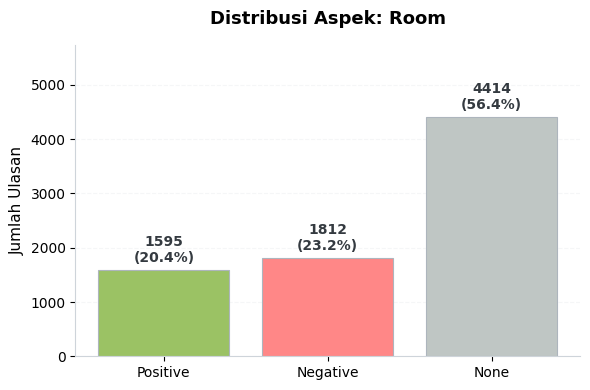

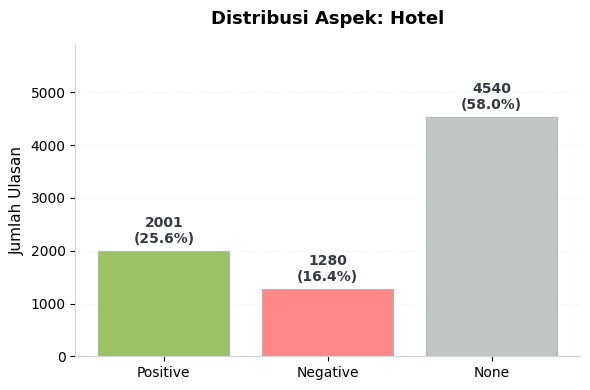

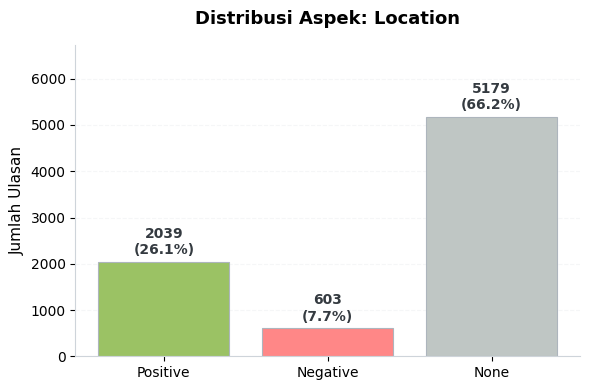

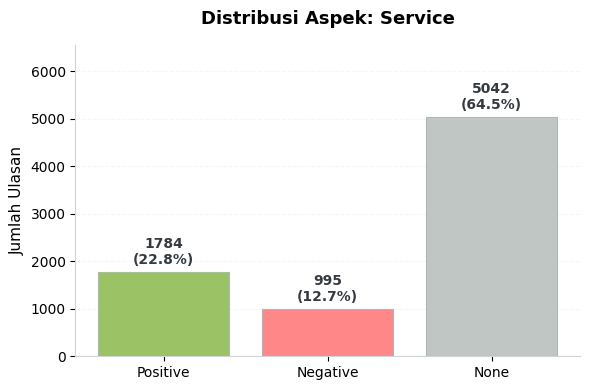

Grafik aspek sudah disimpan di /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Finalisasi_Label/


In [ ]:
import matplotlib.pyplot as plt
import os

label_colors = {
    'Positive': '#9BC264','Negative': '#ff8787','None': '#BFC6C4','Conflict': '#ffd8a8'
}

for aspek in ASPEK_COLS:
    col_final = f"{aspek}_Final"
    dist = df_merged[col_final].value_counts()
    labels_order = [l for l in ['Positive', 'Negative', 'None', 'Conflict'] if l in dist.index]
    counts = [dist[l] for l in labels_order]
    colors = [label_colors[l] for l in labels_order]

    plt.figure(figsize=(6, 4))
    ax = plt.gca()
    bars = ax.bar(labels_order, counts, color=colors, edgecolor='#adb5bd', linewidth=0.8, width=0.8)
    # Menambahkan label angka (fontsize=12)
    for bar, count in zip(bars, counts):
        pct = (count / len(df_merged)) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(counts)*0.02),
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#343a40')

    # Styling Judul dan Label
    ax.set_title(f'Distribusi Aspek: {aspek}', fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel('Jumlah Ulasan', fontsize=11)
    ax.set_ylim(0, max(counts) * 1.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#ced4da')
    ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='#dee2e6')
    ax.set_axisbelow(True)

    filename = f'Distribusi_Label_{aspek.lower()}.png'
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

print(f"Grafik aspek sudah disimpan di {OUTPUT_DIR}")

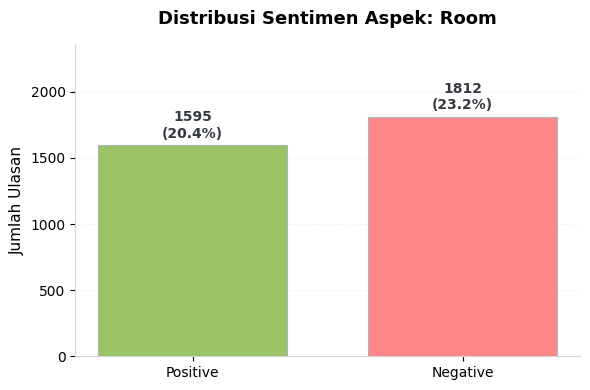

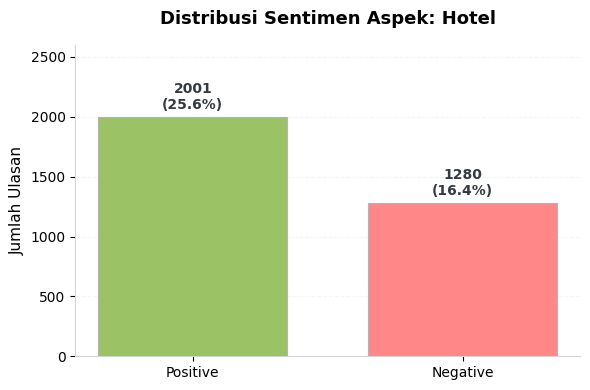

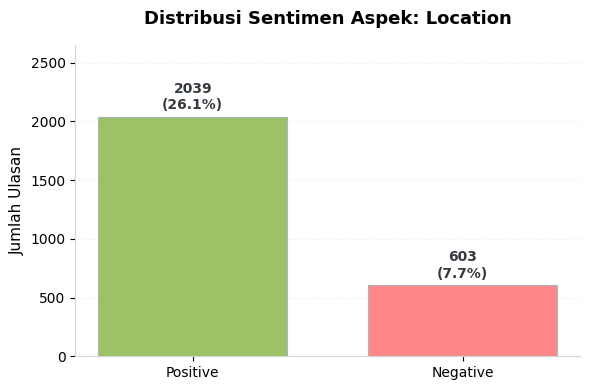

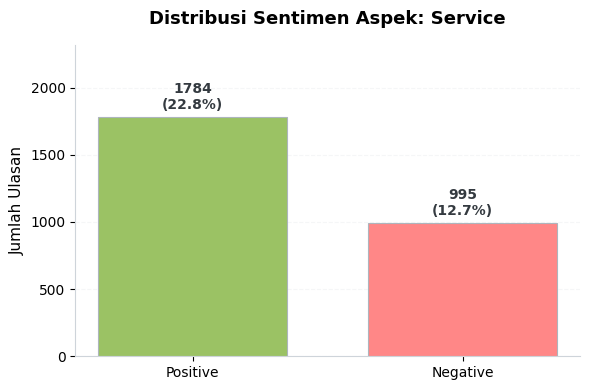

Grafik aspek sudah disimpan di /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Finalisasi_Label/


In [ ]:
import matplotlib.pyplot as plt
import os

label_colors = {
    'Positive': '#9BC264',
    'Negative': '#ff8787',
    'None': '#BFC6C4',
    'Conflict': '#ffd8a8'
}

for aspek in ASPEK_COLS:
    col_final = f"{aspek}_Final"
    dist = df_merged[col_final].value_counts()
    labels_order = [l for l in ['Positive', 'Negative'] if l in dist.index]
    counts = [dist[l] for l in labels_order]
    colors = [label_colors[l] for l in labels_order]

    plt.figure(figsize=(6, 4))
    ax = plt.gca()

    bars = ax.bar(labels_order, counts, color=colors, edgecolor='#adb5bd', linewidth=0.8, width=0.7)

    for bar, count in zip(bars, counts):
        pct = (count / len(df_merged)) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(counts)*0.02),
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#343a40')

    ax.set_title(f'Distribusi Sentimen Aspek: {aspek}', fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel('Jumlah Ulasan', fontsize=11)
    ax.set_ylim(0, max(counts) * 1.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#ced4da')
    ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='#dee2e6')
    ax.set_axisbelow(True)

    filename = f'distribusi_sentimen_label_{aspek.lower()}.png'
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

print(f"Grafik aspek sudah disimpan di {OUTPUT_DIR}")

### 10b. Distribusi 'Dibahas' vs 'Tidak Dibahas' per Aspek

Membuat grafik perbandingan 'Dibahas' vs 'Tidak Dibahas' per aspek...


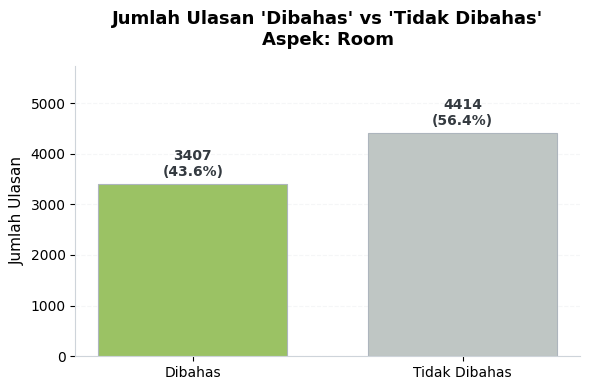

  Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Finalisasi_Label/distribusi_dibahas_vs_tidak_dibahas_room.png


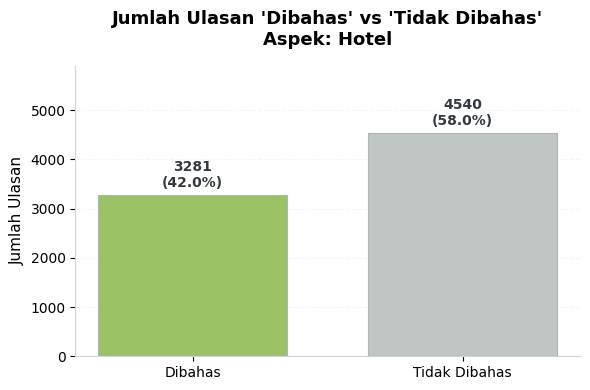

  Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Finalisasi_Label/distribusi_dibahas_vs_tidak_dibahas_hotel.png


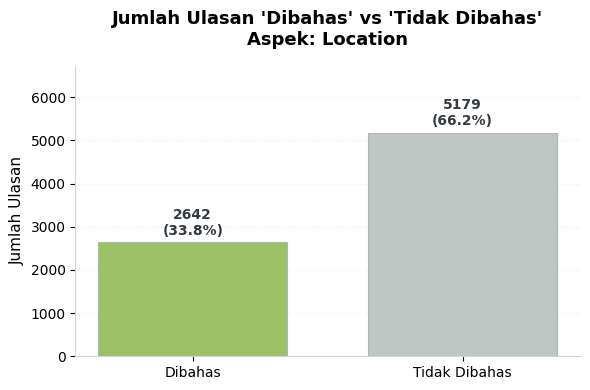

  Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Finalisasi_Label/distribusi_dibahas_vs_tidak_dibahas_location.png


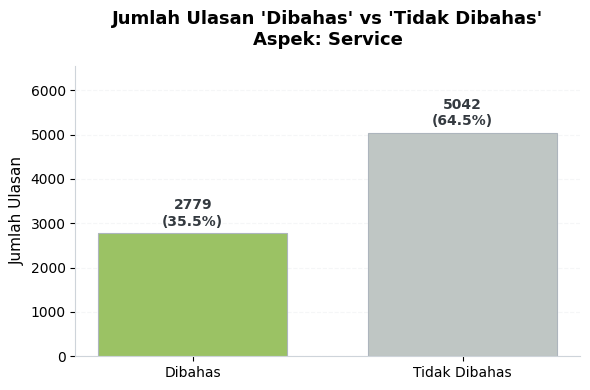

  Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Finalisasi_Label/distribusi_dibahas_vs_tidak_dibahas_service.png
Semua grafik perbandingan 'Dibahas' vs 'Tidak Dibahas' selesai disimpan.


In [ ]:
import matplotlib.pyplot as plt
import os

# Define colors for 'Dibahas' and 'Tidak Dibahas'
dibahas_color = '#9BC264' # A shade of green for 'Dibahas'
tidak_dibahas_color = '#BFC6C4' # Gray for 'None' / 'Tidak Dibahas'

print("Membuat grafik perbandingan 'Dibahas' vs 'Tidak Dibahas' per aspek...")

for aspek in ASPEK_COLS:
    col_final = f"{aspek}_Final"

    # Calculate counts
    count_none = (df_merged[col_final] == 'None').sum()
    count_positive_negative = ((df_merged[col_final] == 'Positive') | \
                               (df_merged[col_final] == 'Negative')).sum()

    # Prepare data for plotting
    labels = ['Dibahas', 'Tidak Dibahas']
    counts = [count_positive_negative, count_none]
    colors = [dibahas_color, tidak_dibahas_color]

    plt.figure(figsize=(6, 4))
    ax = plt.gca()
    bars = ax.bar(labels, counts, color=colors, edgecolor='#adb5bd', linewidth=0.8, width=0.7)

    # Add count and percentage labels on bars
    total = sum(counts)
    for bar, count in zip(bars, counts):
        pct = (count / total) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(counts) * 0.02),
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#343a40')

    # Styling Judul dan Label
    ax.set_title(f"Jumlah Ulasan 'Dibahas' vs 'Tidak Dibahas'\nAspek: {aspek}",
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel('Jumlah Ulasan', fontsize=11)
    ax.set_ylim(0, max(counts) * 1.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#ced4da')
    ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='#dee2e6')
    ax.set_axisbelow(True)

    filename = f'distribusi_dibahas_vs_tidak_dibahas_{aspek.lower()}.png'
    filepath = os.path.join(OUTPUT_DIR, filename)
    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  Disimpan: {filepath}")

print("Semua grafik perbandingan 'Dibahas' vs 'Tidak Dibahas' selesai disimpan.")

### 10c. Distribusi Gabungan (Stacked Bar Chart)

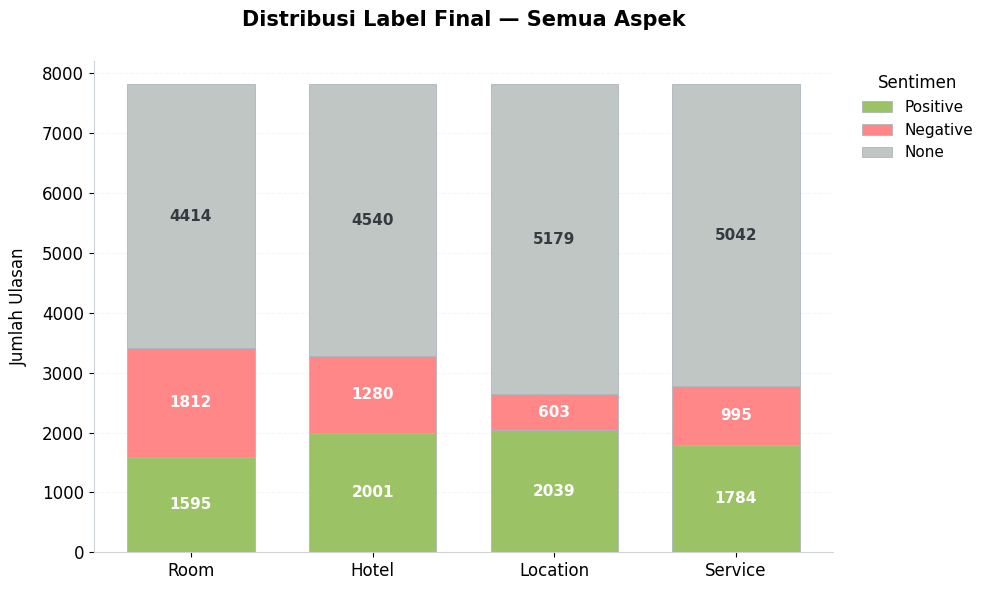

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

label_colors = {
    'Positive': '#9BC264', 'Negative': '#ff8787', 'None': '#BFC6C4', 'Conflict': '#ffd8a8'
}

label_order = ['Positive', 'Negative', 'None']
dist_data = {}
for aspek in ASPEK_COLS:
    vc = df_merged[f"{aspek}_Final"].value_counts()
    dist_data[aspek] = {l: vc.get(l, 0) for l in label_order}

df_dist = pd.DataFrame(dist_data).T

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(ASPEK_COLS))

for label in label_order:
    vals = df_dist[label].values
    bars = ax.bar(df_dist.index, vals, bottom=bottom, color=label_colors[label],
                  label=label, edgecolor='#adb5bd', linewidth=0.6, width=0.7)

    for bar, val, bot in zip(bars, vals, bottom):
        if val > 100:
            # Warna teks adaptif agar terbaca jelas
            text_color = '#343a40' if label == 'None' else 'white'
            ax.text(bar.get_x() + bar.get_width()/2, bot + val/2,
                    f'{int(val)}', ha='center', va='center',
                    fontsize=11, color=text_color, fontweight='bold')
    bottom += vals

ax.set_title('Distribusi Label Final — Semua Aspek', fontsize=15, fontweight='bold', pad=25)
# Label Sumbu Y (Jumlah)
ax.set_ylabel('Jumlah Ulasan', fontsize=12, labelpad=10)
# Label Sumbu X (Nama Aspek di bawah bar)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Sentimen', title_fontsize=12, fontsize=11,
          bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

ax.spines[['top','right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#ced4da')
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='#dee2e6')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'Distribusi_Stacked_Final_AllAspect.png', dpi=300, bbox_inches='tight')
plt.show()

### 10d Visualisasi Keberadaan Aspek dan Sentimen

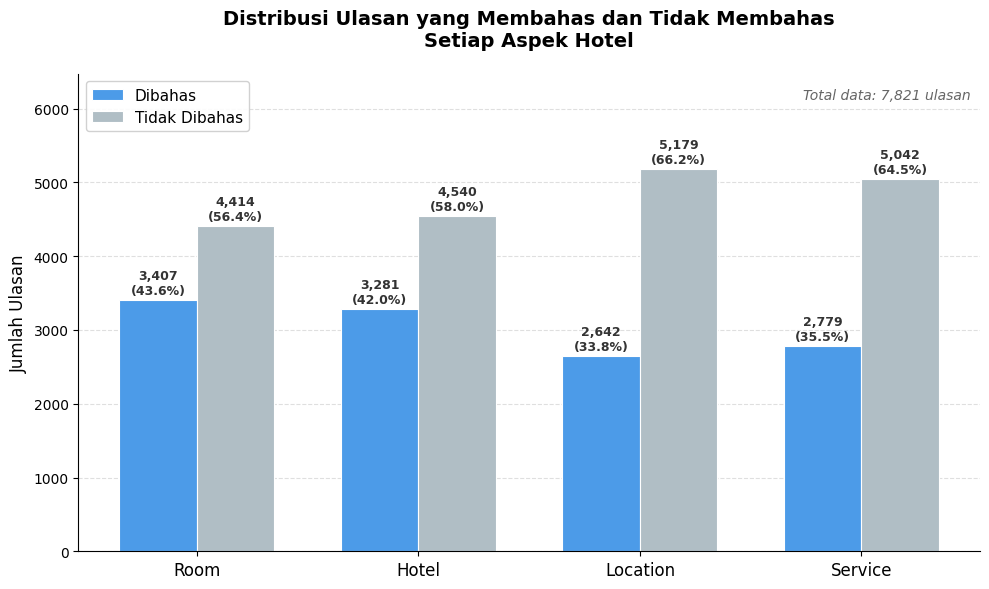

Grafik 1 disimpan!

Ringkasan Grafik 1:
Aspek           Dibahas       %   Tidak Dibahas       %
-------------------------------------------------------
Room              3,407   43.6%           4,414   56.4%
Hotel             3,281   42.0%           4,540   58.0%
Location          2,642   33.8%           5,179   66.2%
Service           2,779   35.5%           5,042   64.5%


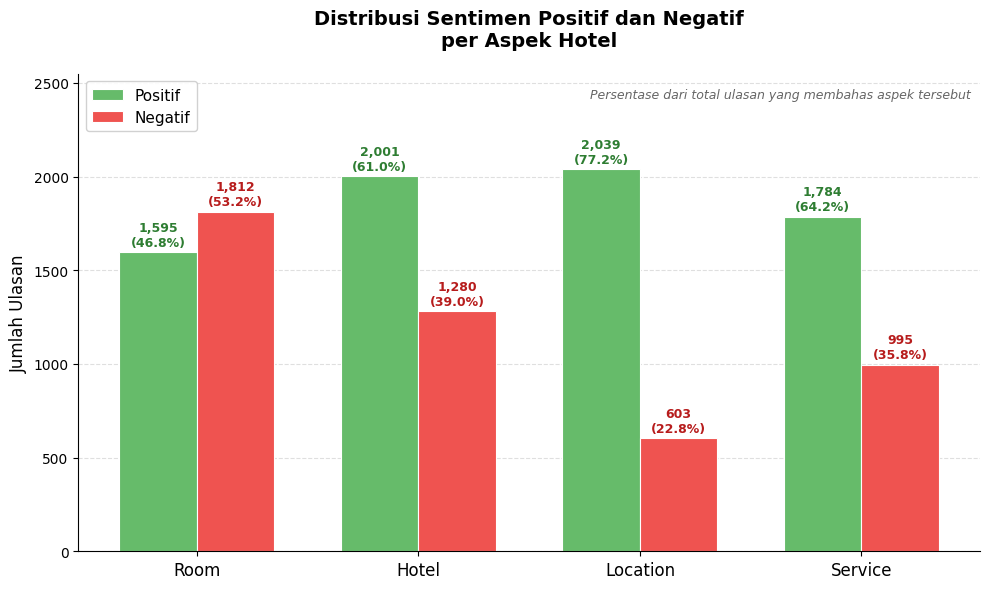


Grafik 2 disimpan!

Ringkasan Grafik 2:
Aspek          Positif       %   Negatif       %   Total Dibahas
-----------------------------------------------------------------
Room             1,595   46.8%     1,812   53.2%           3,407
Hotel            2,001   61.0%     1,280   39.0%           3,281
Location         2,039   77.2%       603   22.8%           2,642
Service          1,784   64.2%       995   35.8%           2,779


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Warna ──
WARNA = {
    'Dibahas'      : '#4C9BE8',   # biru
    'Tidak Dibahas': '#B0BEC5',   # abu
    'Positive'     : '#66BB6A',   # hijau
    'Negative'     : '#EF5350',   # merah
}

ASPEK_COLS = ['Room', 'Hotel', 'Location', 'Service']

# ══════════════════════════════════════════════════════════
# GRAFIK 1
# Dibahas vs Tidak Dibahas per Aspek (Grouped Bar Chart)
# Tujuan: menunjukkan berapa ulasan membahas setiap aspek
# ══════════════════════════════════════════════════════════

fig1, ax1 = plt.subplots(figsize=(10, 6))

x      = np.arange(len(ASPEK_COLS))
width  = 0.35
total  = len(df_merged)

n_dibahas      = []
n_tidak_dibahas = []

for aspek in ASPEK_COLS:
    col    = f"{aspek}_Final"
    n_db   = ((df_merged[col] == 'Positive') | (df_merged[col] == 'Negative')).sum()
    n_tdb  = (df_merged[col] == 'None').sum()
    n_dibahas.append(n_db)
    n_tidak_dibahas.append(n_tdb)

bars1 = ax1.bar(x - width/2, n_dibahas, width,
                color=WARNA['Dibahas'], label='Dibahas',
                edgecolor='white', linewidth=0.8)
bars2 = ax1.bar(x + width/2, n_tidak_dibahas, width,
                color=WARNA['Tidak Dibahas'], label='Tidak Dibahas',
                edgecolor='white', linewidth=0.8)

# Label angka + persentase di atas bar
for bar, val in list(zip(bars1, n_dibahas)) + list(zip(bars2, n_tidak_dibahas)):
    pct = val / total * 100
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f'{val:,}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#333'
    )

ax1.set_xticks(x)
ax1.set_xticklabels(ASPEK_COLS, fontsize=12)
ax1.set_ylabel('Jumlah Ulasan', fontsize=12)
ax1.set_title(
    'Distribusi Ulasan yang Membahas dan Tidak Membahas\nSetiap Aspek Hotel',
    fontsize=14, fontweight='bold', pad=20
)
ax1.set_ylim(0, max(max(n_dibahas), max(n_tidak_dibahas)) * 1.25)
ax1.legend(fontsize=11, framealpha=0.9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)

# Tambah total ulasan sebagai catatan
ax1.text(
    0.99, 0.97,
    f'Total data: {total:,} ulasan',
    transform=ax1.transAxes,
    ha='right', va='top',
    fontsize=10, color='#666',
    style='italic'
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'Grafik1_Dibahas_vs_Tidak_Dibahas.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Grafik 1 disimpan!")

# Cetak tabel ringkasan
print("\nRingkasan Grafik 1:")
print(f"{'Aspek':<12} {'Dibahas':>10} {'%':>7} {'Tidak Dibahas':>15} {'%':>7}")
print("-" * 55)
for aspek, db, tdb in zip(ASPEK_COLS, n_dibahas, n_tidak_dibahas):
    print(f"{aspek:<12} {db:>10,} {db/total*100:>6.1f}% {tdb:>15,} {tdb/total*100:>6.1f}%")


# ══════════════════════════════════════════════════════════
# GRAFIK 2
# Distribusi Sentimen Positif vs Negatif per Aspek
# (hanya ulasan yang MEMBAHAS aspek tersebut)
# ══════════════════════════════════════════════════════════

fig2, ax2 = plt.subplots(figsize=(10, 6))

n_positif = []
n_negatif = []

for aspek in ASPEK_COLS:
    col   = f"{aspek}_Final"
    n_pos = (df_merged[col] == 'Positive').sum()
    n_neg = (df_merged[col] == 'Negative').sum()
    n_positif.append(n_pos)
    n_negatif.append(n_neg)

bars3 = ax2.bar(x - width/2, n_positif, width,
                color=WARNA['Positive'], label='Positif',
                edgecolor='white', linewidth=0.8)
bars4 = ax2.bar(x + width/2, n_negatif, width,
                color=WARNA['Negative'], label='Negatif',
                edgecolor='white', linewidth=0.8)

# Label angka + persentase (dari total yang dibahas per aspek)
for i_aspek, (b3, b4, pos, neg) in enumerate(
        zip(bars3, bars4, n_positif, n_negatif)):
    total_dibahas = pos + neg
    if total_dibahas == 0:
        continue

    pct_pos = pos / total_dibahas * 100
    pct_neg = neg / total_dibahas * 100

    ax2.text(
        b3.get_x() + b3.get_width() / 2,
        b3.get_height() + 20,
        f'{pos:,}\n({pct_pos:.1f}%)',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#2e7d32'
    )
    ax2.text(
        b4.get_x() + b4.get_width() / 2,
        b4.get_height() + 20,
        f'{neg:,}\n({pct_neg:.1f}%)',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#b71c1c'
    )

ax2.set_xticks(x)
ax2.set_xticklabels(ASPEK_COLS, fontsize=12)
ax2.set_ylabel('Jumlah Ulasan', fontsize=12)
ax2.set_title(
    'Distribusi Sentimen Positif dan Negatif\nper Aspek Hotel',
    fontsize=14, fontweight='bold', pad=20
)
ax2.set_ylim(0, max(max(n_positif), max(n_negatif)) * 1.25)
ax2.legend(fontsize=11, framealpha=0.9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)

ax2.text(
    0.99, 0.97,
    'Persentase dari total ulasan yang membahas aspek tersebut',
    transform=ax2.transAxes,
    ha='right', va='top',
    fontsize=9, color='#666',
    style='italic'
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'Grafik2_Sentimen_Positif_vs_Negatif.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("\nGrafik 2 disimpan!")

# Cetak tabel ringkasan
print("\nRingkasan Grafik 2:")
print(f"{'Aspek':<12} {'Positif':>9} {'%':>7} {'Negatif':>9} {'%':>7} {'Total Dibahas':>15}")
print("-" * 65)
for aspek, pos, neg in zip(ASPEK_COLS, n_positif, n_negatif):
    tot = pos + neg
    print(f"{aspek:<12} {pos:>9,} {pos/tot*100:>6.1f}% {neg:>9,} {neg/tot*100:>6.1f}% {tot:>15,}")

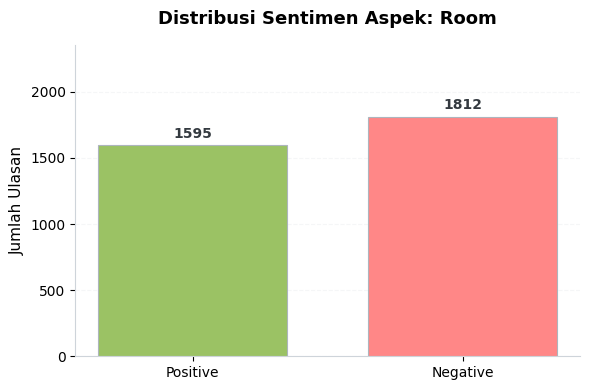

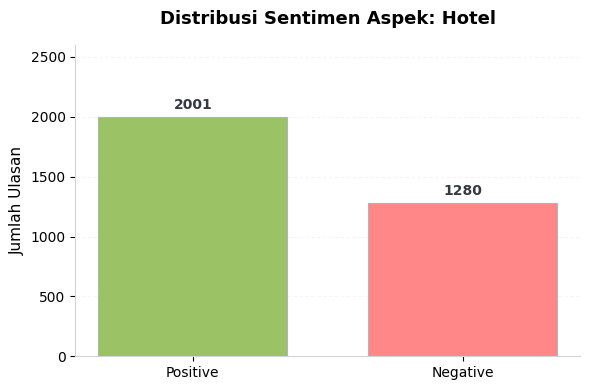

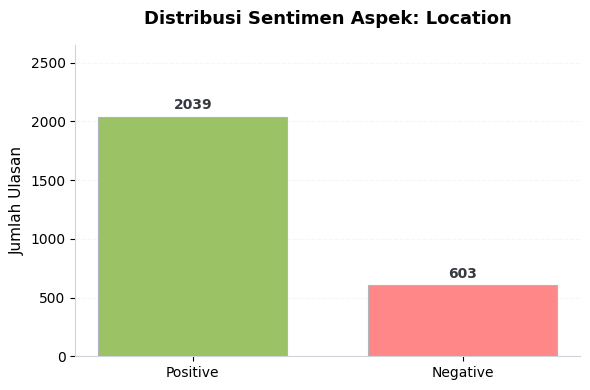

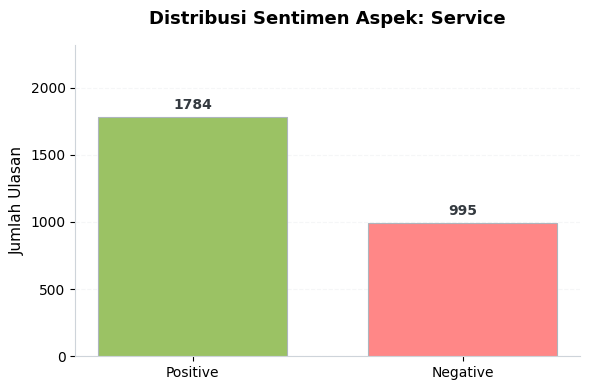

Grafik aspek sudah disimpan di /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Finalisasi_Label/


In [15]:
import matplotlib.pyplot as plt
import os

label_colors = {
    'Positive': '#9BC264',
    'Negative': '#ff8787',
    'None': '#BFC6C4',
    'Conflict': '#ffd8a8'
}

for aspek in ASPEK_COLS:
    col_final = f"{aspek}_Final"
    dist = df_merged[col_final].value_counts()
    labels_order = [l for l in ['Positive', 'Negative'] if l in dist.index]
    counts = [dist[l] for l in labels_order]
    colors = [label_colors[l] for l in labels_order]

    plt.figure(figsize=(6, 4))
    ax = plt.gca()

    bars = ax.bar(labels_order, counts, color=colors, edgecolor='#adb5bd', linewidth=0.8, width=0.7)

    # BAGIAN YANG DIUBAH: Menghilangkan perhitungan persen dan menyederhanakan teks
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(counts)*0.02),
                f'{count}', ha='center', va='bottom', # Hanya menampilkan count
                fontsize=10, fontweight='bold', color='#343a40')

    ax.set_title(f'Distribusi Sentimen Aspek: {aspek}', fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel('Jumlah Ulasan', fontsize=11)
    ax.set_ylim(0, max(counts) * 1.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#ced4da')
    ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='#dee2e6')
    ax.set_axisbelow(True)

    filename = f'distribusi_sentimen_label_{aspek.lower()}.png'
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

print(f"Grafik aspek sudah disimpan di {OUTPUT_DIR}")

### 10c. WordCloud per Aspek
WordCloud dibuat dari `review_text_translated` untuk ulasan yang memiliki sentimen **Positive** atau **Negative** pada masing-masing aspek

In [ ]:
TEXT_FOR_WC = TRANS_COL if TRANS_COL in df_merged.columns else TEXT_COL

def buat_wordcloud(teks_series, judul, warna, filepath):
    """fungsi buat dan simpan WordCloud sebagai file tersendiri."""
    gabung = ' '.join(teks_series.dropna().astype(str).tolist())

    fig, ax = plt.subplots(figsize=(10, 6))

    if len(gabung.strip()) == 0:
        ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center',
                transform=ax.transAxes, fontsize=14)
        ax.set_title(judul, fontsize=13, fontweight='bold', pad=12)
        ax.axis('off')
    else:
        wc = WordCloud(width=900, height=550, background_color='white',
                       colormap=warna, max_words=80, collocations=False).generate(gabung)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(judul, fontsize=13, fontweight='bold', pad=12)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  Disimpan: {filepath}")


# Wordcloud terpisah per aspek per sentimen
print("Membuat WordCloud per Aspek...\n")
for aspek in ASPEK_COLS:
    col_final = f"{aspek}_Final"
    teks_pos  = df_merged[df_merged[col_final] == 'Positive'][TEXT_FOR_WC]
    teks_neg  = df_merged[df_merged[col_final] == 'Negative'][TEXT_FOR_WC]

    print(f"[{aspek}]")
    buat_wordcloud(
        teks_pos,
        f"WordCloud {aspek} — Positive ({len(teks_pos)} ulasan)",
        'Greens',
        OUTPUT_DIR + f'wordcloud_{aspek.lower()}_positive.png'
    )
    buat_wordcloud(
        teks_neg,
        f"WordCloud {aspek} — Negative ({len(teks_neg)} ulasan)",
        'Reds',
        OUTPUT_DIR + f'wordcloud_{aspek.lower()}_negative.png'
    )

print("\nSemua WordCloud selesai disimpan.")

Output hidden; open in https://colab.research.google.com to view.

In [12]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os

TEXT_FOR_WC = TRANS_COL if TRANS_COL in df_merged.columns else TEXT_COL

def buat_wordcloud(teks_series, judul, warna_pilihan, filepath):
    """fungsi buat dan simpan WordCloud dengan warna yang lebih kontras."""
    gabung = ' '.join(teks_series.dropna().astype(str).tolist())

    fig, ax = plt.subplots(figsize=(10, 6))

    if len(gabung.strip()) == 0:
        ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center',
                transform=ax.transAxes, fontsize=14)
        ax.set_title(judul, fontsize=13, fontweight='bold', pad=12)
        ax.axis('off')
    else:
        wc = WordCloud(width=900, height=550,
                       background_color='white',
                       colormap=warna_pilihan, # Kita ganti colormap-nya di sini
                       max_words=80,
                       collocations=False,
                       prefer_horizontal=0.7).generate(gabung)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(judul, fontsize=13, fontweight='bold', pad=12)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"   Disimpan: {filepath}")

# Wordcloud terpisah per aspek per sentimen
print("Membuat WordCloud per Aspek...\n")
for aspek in ASPEK_COLS:
    col_final = f"{aspek}_Final"
    teks_pos  = df_merged[df_merged[col_final] == 'Positive'][TEXT_FOR_WC]
    teks_neg  = df_merged[df_merged[col_final] == 'Negative'][TEXT_FOR_WC]

    print(f"[{aspek}]")

    buat_wordcloud(
        teks_pos,
        f"WordCloud {aspek} — Positive ({len(teks_pos)} ulasan)",
        'summer',
        os.path.join(OUTPUT_DIR, f'wordcloud_{aspek.lower()}_positive.png')
    )
    buat_wordcloud(
        teks_neg,
        f"WordCloud {aspek} — Negative ({len(teks_neg)} ulasan)",
        'autumn',
        os.path.join(OUTPUT_DIR, f'wordcloud_{aspek.lower()}_negative.png')
    )

print("\nSemua WordCloud selesai disimpan.")

Output hidden; open in https://colab.research.google.com to view.

Menampilkan WordCloud Global...



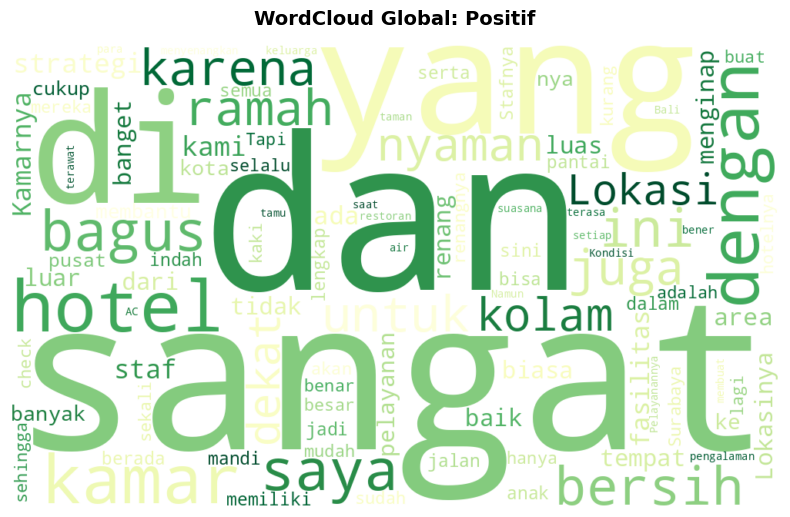

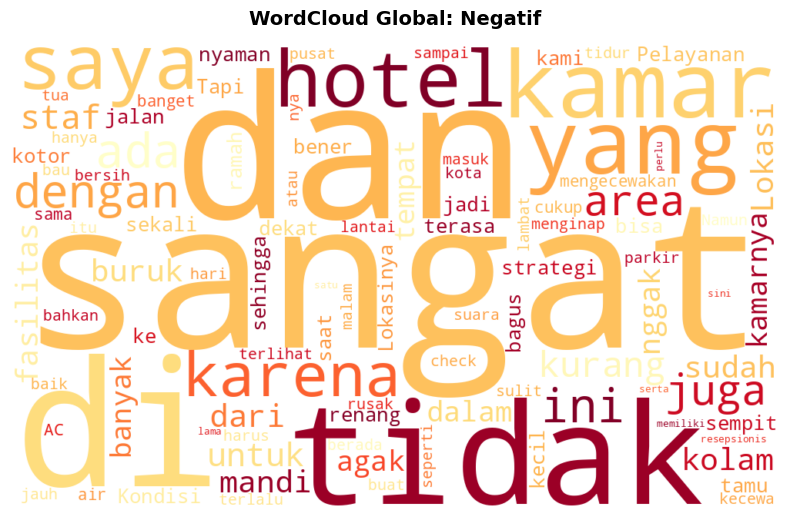

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. Inisialisasi list untuk menampung teks
all_pos_text = []
all_neg_text = []

# 2. Iterasi melalui setiap kolom aspek
for aspek in ASPEK_COLS:
    col_final = f"{aspek}_Final"

    # Ambil teks ulasan (Positive & Negative)
    pos_samples = df_merged[df_merged[col_final] == 'Positive'][TEXT_FOR_WC].dropna().tolist()
    neg_samples = df_merged[df_merged[col_final] == 'Negative'][TEXT_FOR_WC].dropna().tolist()

    all_pos_text.extend(pos_samples)
    all_neg_text.extend(neg_samples)

# 3. Hapus duplikasi agar satu ulasan dihitung 1x per kategori
all_pos_series = pd.Series(list(set(all_pos_text)))
all_neg_series = pd.Series(list(set(all_neg_text)))

# 4. Fungsi untuk TAMPILKAN WordCloud (Tanpa simpan)
def tampilkan_wc(data_series, title, color):
    full_text = ' '.join(data_series.astype(str).tolist())

    if not full_text.strip():
        print(f"Tidak ada data untuk {title}")
        return

    wc = WordCloud(
        width=1000,
        height=600,
        background_color='white',
        colormap=color,
        max_words=100,
        collocations=False,
        prefer_horizontal=0.8
    ).generate(full_text)

    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.axis('off')
    plt.show() # Hanya menampilkan di output

# 5. Eksekusi
print("Menampilkan WordCloud Global...\n")

tampilkan_wc(all_pos_series, "WordCloud Global: Positif", 'YlGn')
tampilkan_wc(all_neg_series, "WordCloud Global: Negatif", 'YlOrRd')

In [12]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os

# 1. Definisi Stopwords berdasarkan evaluasi visual sebelumnya
# Kata 'hotel' TIDAK dimasukkan agar tetap muncul di aspek terkait
stopwords_id = {
    'sangat', 'dan', 'yang', 'di', 'ini', 'itu', 'dengan', 'untuk', 'ada',
    'dari', 'karena', 'juga', 'saya', 'kami', 'ke', 'sudah', 'bisa', 'saat',
    'adalah', 'sehingga', 'tapi', 'namun', 'hanya', 'atau', 'jadi', 'tidak',
    'agak', 'terasa', 'secara', 'serta', 'bagi', 'nya', 'maupun', 'ingin',
    'kalau', 'kalo', 'banget', 'aja', 'ya', 'eh', 'sih', 'kok', 'tersebut'
}

TEXT_FOR_WC = TRANS_COL if TRANS_COL in df_merged.columns else TEXT_COL

def buat_wordcloud(teks_series, judul, warna_pilihan, filepath):
    """fungsi buat dan simpan WordCloud tanpa stopwords fungsional."""
    gabung = ' '.join(teks_series.dropna().astype(str).tolist())

    fig, ax = plt.subplots(figsize=(10, 6))

    if len(gabung.strip()) == 0:
        ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center',
                transform=ax.transAxes, fontsize=14)
        ax.set_title(judul, fontsize=13, fontweight='bold', pad=12)
        ax.axis('off')
    else:
        # Menambahkan parameter stopwords=stopwords_id
        wc = WordCloud(width=900, height=550,
                       background_color='white',
                       colormap=warna_pilihan,
                       max_words=80,
                       collocations=False,
                       stopwords=stopwords_id, # Filter kata tidak bermakna
                       prefer_horizontal=0.7).generate(gabung)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(judul, fontsize=13, fontweight='bold', pad=12)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"   Disimpan: {filepath}")


# Wordcloud terpisah per aspek per sentimen
print("Membuat WordCloud per Aspek (Tanpa Stopwords)...\n")
for aspek in ASPEK_COLS:
    col_final = f"{aspek}_Final"
    teks_pos  = df_merged[df_merged[col_final] == 'Positive'][TEXT_FOR_WC]
    teks_neg  = df_merged[df_merged[col_final] == 'Negative'][TEXT_FOR_WC]

    print(f"[{aspek}]")

    buat_wordcloud(
        teks_pos,
        f"WordCloud {aspek} — Positive ({len(teks_pos)} ulasan)",
        'summer',
        os.path.join(OUTPUT_DIR, f'wordcloud_{aspek.lower()}_positive.png')
    )
    buat_wordcloud(
        teks_neg,
        f"WordCloud {aspek} — Negative ({len(teks_neg)} ulasan)",
        'autumn',
        os.path.join(OUTPUT_DIR, f'wordcloud_{aspek.lower()}_negative.png')
    )

print("\nSemua WordCloud selesai disimpan.")

Output hidden; open in https://colab.research.google.com to view.

In [14]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os
import re

# 1. Definisi Stopwords
stopwords_id = {
    'sangat', 'dan', 'yang', 'di', 'ini', 'itu', 'dengan', 'untuk', 'ada',
    'dari', 'karena', 'juga', 'saya', 'kami', 'ke', 'sudah', 'bisa', 'saat',
    'adalah', 'sehingga', 'tapi', 'namun', 'hanya', 'atau', 'jadi', 'tidak',
    'agak', 'terasa', 'secara', 'serta', 'bagi', 'nya', 'maupun', 'ingin',
    'kalau', 'kalo', 'banget', 'aja', 'ya', 'eh', 'sih', 'kok', 'tersebut',
    'dalam', 'beberapa', 'mengenai', 'adapun', 'masih', 'hotel'
}

TEXT_FOR_WC = TRANS_COL if TRANS_COL in df_merged.columns else TEXT_COL

def buat_wordcloud(teks_series, judul, warna_pilihan, filepath):
    """fungsi buat dan simpan WordCloud dengan perbaikan stemming."""

    # PERBAIKAN: Mengembalikan kata 'strategi' menjadi 'strategis' agar lebih informatif
    # Kita gunakan regex \b agar hanya mengubah kata yang tepat (exact match)
    teks_clean = teks_series.astype(str).str.replace(r'\bstrategi\b', 'strategis', regex=True)

    gabung = ' '.join(teks_clean.dropna().tolist())

    fig, ax = plt.subplots(figsize=(10, 6))

    if len(gabung.strip()) == 0:
        ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center',
                transform=ax.transAxes, fontsize=14)
        ax.set_title(judul, fontsize=13, fontweight='bold', pad=12)
        ax.axis('off')
    else:
        wc = WordCloud(width=900, height=550,
                       background_color='white',
                       colormap=warna_pilihan,
                       max_words=80,
                       collocations=False,
                       stopwords=stopwords_id,
                       prefer_horizontal=0.7).generate(gabung)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(judul, fontsize=13, fontweight='bold', pad=12)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"   Disimpan: {filepath}")

# Wordcloud terpisah per aspek per sentimen
print("Membuat WordCloud per Aspek (dengan perbaikan kata)...\n")
for aspek in ASPEK_COLS:
    col_final = f"{aspek}_Final"
    teks_pos  = df_merged[df_merged[col_final] == 'Positive'][TEXT_FOR_WC]
    teks_neg  = df_merged[df_merged[col_final] == 'Negative'][TEXT_FOR_WC]

    print(f"[{aspek}]")

    buat_wordcloud(
        teks_pos,
        f"WordCloud {aspek} — Positive ({len(teks_pos)} ulasan)",
        'summer',
        os.path.join(OUTPUT_DIR, f'wordcloud_{aspek.lower()}_positive.png')
    )
    buat_wordcloud(
        teks_neg,
        f"WordCloud {aspek} — Negative ({len(teks_neg)} ulasan)",
        'autumn',
        os.path.join(OUTPUT_DIR, f'wordcloud_{aspek.lower()}_negative.png')
    )

print("\nSemua WordCloud selesai disimpan.")

Output hidden; open in https://colab.research.google.com to view.

In [11]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os

# 1. Definisi Stopwords berdasarkan evaluasi visual sebelumnya
# Kata 'hotel' TIDAK dimasukkan agar tetap muncul di aspek terkait
stopwords_id = {
    'sangat', 'dan', 'yang', 'di', 'ini', 'itu', 'dengan', 'untuk', 'ada',
    'dari', 'karena', 'juga', 'saya', 'kami', 'ke', 'sudah', 'bisa', 'saat',
    'adalah', 'sehingga', 'tapi', 'namun', 'hanya', 'atau', 'jadi',
    'agak', 'terasa', 'secara', 'serta', 'bagi', 'nya', 'maupun', 'ingin',
    'kalau', 'kalo', 'banget', 'aja', 'ya', 'eh', 'sih', 'kok', 'tersebut'
}

TEXT_FOR_WC = TRANS_COL if TRANS_COL in df_merged.columns else TEXT_COL

def buat_wordcloud(teks_series, judul, warna_pilihan, filepath):
    """fungsi buat dan simpan WordCloud tanpa stopwords fungsional."""
    gabung = ' '.join(teks_series.dropna().astype(str).tolist())

    fig, ax = plt.subplots(figsize=(10, 6))

    if len(gabung.strip()) == 0:
        ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center',
                transform=ax.transAxes, fontsize=14)
        ax.set_title(judul, fontsize=13, fontweight='bold', pad=12)
        ax.axis('off')
    else:
        # Menambahkan parameter stopwords=stopwords_id
        wc = WordCloud(width=900, height=550,
                       background_color='white',
                       colormap=warna_pilihan,
                       max_words=80,
                       collocations=False,
                       stopwords=stopwords_id, # Filter kata tidak bermakna
                       prefer_horizontal=0.7).generate(gabung)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(judul, fontsize=13, fontweight='bold', pad=12)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"   Disimpan: {filepath}")


# Wordcloud terpisah per aspek per sentimen
print("Membuat WordCloud per Aspek (Tanpa Stopwords)...\n")
for aspek in ASPEK_COLS:
    col_final = f"{aspek}_Final"
    teks_pos  = df_merged[df_merged[col_final] == 'Positive'][TEXT_FOR_WC]
    teks_neg  = df_merged[df_merged[col_final] == 'Negative'][TEXT_FOR_WC]

    print(f"[{aspek}]")

    buat_wordcloud(
        teks_pos,
        f"WordCloud {aspek} — Positive ({len(teks_pos)} ulasan)",
        'summer',
        os.path.join(OUTPUT_DIR, f'wordcloud_{aspek.lower()}_positive.png')
    )
    buat_wordcloud(
        teks_neg,
        f"WordCloud {aspek} — Negative ({len(teks_neg)} ulasan)",
        'autumn',
        os.path.join(OUTPUT_DIR, f'wordcloud_{aspek.lower()}_negative.png')
    )

print("\nSemua WordCloud selesai disimpan.")

Output hidden; open in https://colab.research.google.com to view.

## 11. Ringkasan

In [ ]:
print("=" * 70)
print("    RINGKASAN INTER-ANNOTATOR AGREEMENT")
print("=" * 70)
print(f"\nTotal data  : {len(df_merged)} ulasan")
print(f"Anotator    : A1, A2, A3")
print(f"Aspek       : {', '.join(ASPEK_COLS)}")

print("\nKrippendorff's Alpha:")
print(df_alpha[['Aspek', "Krippendorff's Alpha", 'Interpretasi (Skema A)', 'Interpretasi (Skema B)']].to_string(index=False))

print("\nMajority Voting:")
for aspek in ASPEK_COLS:
    n_conflict = (df_merged[f"{aspek}_Final"] == 'Conflict').sum()
    print(f"  {aspek:12s}: {len(df_merged)-n_conflict} resolved, {n_conflict} conflict")

print(f"\nOutput file : {OUTPUT_FILE}")
print("=" * 70)

    RINGKASAN INTER-ANNOTATOR AGREEMENT

Total data  : 7821 ulasan
Anotator    : A1, A2, A3
Aspek       : Room, Hotel, Location, Service

Krippendorff's Alpha:
      Aspek  Krippendorff's Alpha Interpretasi (Skema A) Interpretasi (Skema B)
       Room                0.9585               Reliabel Near-Perfect Agreement
      Hotel                0.9386               Reliabel Near-Perfect Agreement
   Location                0.9639               Reliabel Near-Perfect Agreement
    Service                0.9636               Reliabel Near-Perfect Agreement
KESELURUHAN                0.9561               Reliabel Near-Perfect Agreement

Majority Voting:
  Room        : 7821 resolved, 0 conflict
  Hotel       : 7821 resolved, 0 conflict
  Location    : 7821 resolved, 0 conflict
  Service     : 7821 resolved, 0 conflict

Output file : /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/Finalisasi_Label/Hasil_Pelabelan_Final.xlsx


In [ ]:
# Gabungkan Data Hasil Pelabelan dengan Dataset Awal (Dataset Metadata)
# Load dataset awal yang lengkap
df_awal = pd.read_excel('/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Translated/hotel_reviews_translated.xlsx')

# Merge dengan label final berdasarkan id
df_dataset_final = df_awal.merge(
    df_final[['id', 'Room', 'Hotel', 'Location', 'Service']],
    on='id',
    how='inner'
)

# Simpan sebagai dataset lengkap siap preprocessing
output_path = "/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/hotel_reviews_labelled.xlsx"
df_dataset_final.to_excel(output_path, index=False)
print(f"Dataset lengkap disimpan: {output_path}")
print(f"Shape: {df_dataset_final.shape}")
print(f"Kolom: {df_dataset_final.columns.tolist()}")

Dataset lengkap disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Pelabelan/hotel_reviews_labelled.xlsx
Shape: (7821, 17)
Kolom: ['id', 'review_text', 'review_rating', 'review_date', 'url', 'username', 'hotel_name', 'city', 'hotel_rating', 'region', 'language', 'detected_language', 'review_text_translated', 'Room', 'Hotel', 'Location', 'Service']
